In [60]:
### 读取数据
# ! pip install numpy
import numpy as np
data = np.loadtxt(fname='movielens_100k.csv', delimiter=',',dtype=int)
print(data.shape)
data[:,:2] = data[:, :2] -1 
print(data)

user = set()
item = set()
for i, j, k in data:
    user.add(i)
    item.add(j)
print(f"用户数量为 {len(user)}，电影数量为 {len(item)}。")

(100000, 3)
[[ 195  241    3]
 [ 185  301    3]
 [  21  376    1]
 ...
 [ 275 1089    1]
 [  12  224    2]
 [  11  202    3]]
用户数量为 943，电影数量为 1682。


In [61]:
### 划分数据集合
seed = 10086
np.random.seed(seed)
index = np.random.permutation(range(len(data)))
data = data[index]
split = int(0.8 * len(data))
train = data[:split]
test = data[split:]
print(train)

[[ 502  180    5]
 [ 252   81    3]
 [ 151 1135    5]
 ...
 [ 319   65    4]
 [ 243  213    5]
 [  24  407    5]]


In [62]:
### 使用numpy中的bincount对于哪一个非负整数进行计数
user_count = np.bincount(train[:,0], minlength = len(user))
item_count = np.bincount(train[:,1],minlength=len(item))
print(user_count[:10])
print(item_count[:10])
user_train, user_test = train[:,0], test[:,0]
item_train, item_test = train[:,1], test[:,1] 
y_train, y_test = train[:,2], test[:,2]

[218  49  42  23 130 177 316  43  19 146]
[359 107  69 171  64  20 314 178 245  68]


In [63]:
class MF:
    def __init__(self, N, M, D):
        '''
        N:用户数量
        M:电影数量
        D:特征维度，偏好维度
        '''
        self.user_params = np.zeros(shape = [N,D])
        self.item_params = np.zeros(shape=[M,D])
    
    def pred(self, user_id, item_id):
        a = self.user_params[user_id]
        b = self.item_params[item_id]
        c = np.sum(a * b, axis=1)
        return c
    
    def update(self, user_grad, item_grad, lr): ### side effect
        self.user_params -= lr*user_grad
        self.item_params -= lr*item_grad
        return self


In [64]:
from tqdm import tqdm
def train(model: MF, learning_rate, lbd, max_training_steps, batch_size):
    train_loss, test_loss = [], []
    batch_num = int(np.ceil(len(user_train) / batch_size)) ## 该命令产生的是np.float
    with tqdm(range(max_training_steps)) as pbar:
        for i in range(max_training_steps):
            train_rmse = 0
            for j in range(batch_num):
                start = j * batch_size
                end = min(len(user_train), start + batch_size)
                user_batch = user_train[start: end]
                item_batch = item_train[start: end]
                y_batch = y_train[start: end]
                assert len(user_train) == len(item_train) == len(y_train), \
    f"长度不一致: {len(user_train)}, {len(item_train)}, {len(y_train)}"
                pred = model.pred(user_batch, item_batch)
                errs = pred - y_batch
                P = model.user_params
                Q = model.item_params
                P_grad = np.zeros_like(P)
                Q_grad = np.zeros_like(Q)
                for user, item, err in zip(user_batch, item_batch, errs):
                    P_grad[user] = P_grad[user] - err * Q[item] + lbd * P[user]
                    Q_grad[item] = Q_grad[item] - err * P[user] + lbd * Q[item]
                model.update(P_grad / len(user_batch), Q_grad / len(user_batch), learning_rate )
                train_rmse += np.mean(errs ** 2) 
            
                pbar.set_postfix(
                    {'training epoch': i,
                     'Training Rmse': f"{np.sqrt(train_rmse / (j + 1))}",
                     'Testing Rmse': test_loss[-1] if test_loss else None}
                )
                pbar.update(1)
            
            train_rmse = np.sqrt(train_rmse / len(user_train))
            train_loss.append(train_rmse)
            y_test_pred = model.pred(user_test, item_test)
            test_rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
            test_loss.append(test_rmse)
    return train_loss, test_loss


In [67]:
feature_num = 16
learning_rate = 0.1
lbd = 1e-4
max_training_step = 30
batch_size = 64
model = MF(len(user), len(item), feature_num)
train_loss, test_loss = train(model, learning_rate , lbd, max_training_step, batch_size)

18999it [00:14, 1344.18it/s, training epoch=15, Training Rmse=3.7006080581439584, Testing Rmse=3.7]                    


KeyboardInterrupt: 

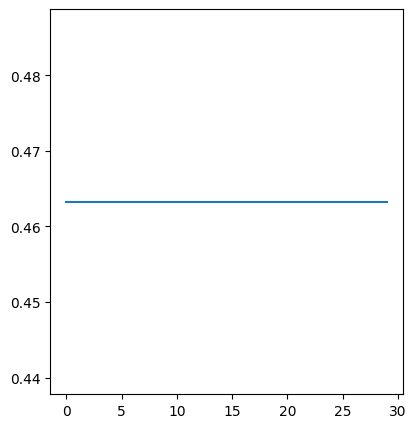

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(train_loss)